# CS2 Lecture 3 — optional

안 풀어도 됨. numpy·pandas로 다차원 리스트 다뤄보는 것. 빈칸(`# ADD`)만 채우면 된다.

## 0. numpy 맛보기

`np.array` 는 다차원 리스트처럼 생겼는데 for 루프 없이 통째로 계산되고
축(axis) 방향으로 합·평균이 된다. 아래는 그냥 실행해서 결과만 보면 된다.

In [ ]:
import numpy as np


A = np.arange(12).reshape(3, 4)
print("A", A)
print()


# for 루프 없이 이렇게 다룬다 — 실행해서 결과만 확인

print("A[:, 1]", A[:, 1])              # 1번 열
print()
print("A.sum(axis=1)", A.sum(axis=1))  # 각 행의 합
print()
print("A[1:3, 1:3]", A[1:3, 1:3])      # 행 1~2, 열 1~2 부분 블록
print()
print("(A > 5).sum()", (A > 5).sum())  # 5 보다 큰 원소 개수


## 1. 이미지 흐리기 (box blur)

흑백 이미지 = `H×W` 2차원 리스트, `image[i][j]` 는 밝기 `0`~`255`.

Problem 6의 `countMines` 와 **구조가 똑같다** — 각 칸에서 3×3 이웃을 훑는데,
지뢰 **개수**를 세는 대신 이웃 밝기의 **합**을 구해서 이웃 수로 나눈다(평균).
그러면 이미지가 흐려진다.

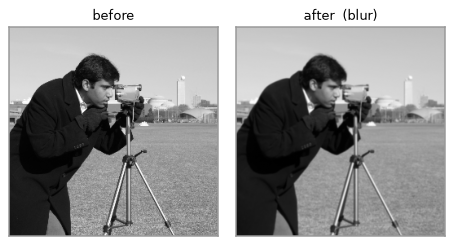

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.data import camera


g = camera().tolist()   # 512 x 512 흑백 이미지 = 2차원 리스트 (밝기 0~255)


def withinBoundary(height, width, i, j):
    return i >= 0 and i < height and j >= 0 and j < width


def blur(image):
    height = len(image)
    width = len(image[0])

    out = np.zeros((height, width))  # out = [[0.0] * width for _ in range(height)]

    for i in range(height):
        for j in range(width):
            # ADD ADDITIONAL CODE HERE!
            # 힌트: (i, j) 의 3x3 이웃을  for k in range(i - 1, i + 2),
            #       for w in range(j - 1, j + 2)  로 돌면서, withinBoundary(...) 인
            #       칸만 image[k][w] 를 더하고 개수를 센 뒤  out[i][j] = 합 / 개수
            pass

    return out


print(blur([[0, 0, 0], [0, 9, 0], [0, 0, 0]])[1][1])   # 1.0


plt.imshow(blur(g), cmap="gray")
plt.show()


## 2. 흰 배경에서 객체만 잘라내기

Problem 7 `maxZeroRect` 와 **같은 방식** — `zeroRect(M, i1, i2, j1, j2)` 처럼
사각형을 판정하는 헬퍼 `coversAll(g, i1, i2, j1, j2)` ("배경이 아닌 픽셀이
전부 이 사각형 안에 있나?") 를 만들고, `maxZeroRect` 처럼 모든
`(i1, j1, i2, j2)` 를 훑어 조건을 만족하는 사각형 중 **넓이가 최소**인 것을
찾는다. 그 사각형으로 자른 게 객체를 감싸는 가장 작은 직사각형.

(격자를 작게 쓰는 이유: 이 4중 루프는 Problem 7처럼 무거워서 큰 이미지엔 못 쓴다.)

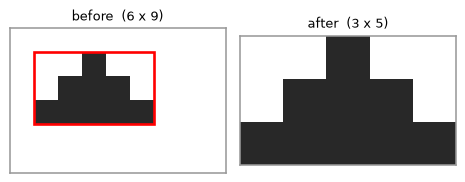

In [ ]:
import matplotlib.pyplot as plt


W, X = 255, 40   # 흰 배경 / 어두운 객체

g = [[W, W, W, W, W, W, W, W, W],
     [W, W, W, X, W, W, W, W, W],
     [W, W, X, X, X, W, W, W, W],
     [W, X, X, X, X, X, W, W, W],
     [W, W, W, W, W, W, W, W, W],
     [W, W, W, W, W, W, W, W, W]]


def coversAll(g, i1, i2, j1, j2, thresh=250):
    # ADD ADDITIONAL CODE HERE!
    # 배경이 아닌 픽셀(g[i][j] < thresh)이 하나라도 사각형 [i1..i2] x [j1..j2]
    # 밖에 있으면 False, 다 안에 있으면 True   (Problem 7 zeroRect 와 같은 꼴)
    pass


def minCropRect(g, thresh=250):
    # ADD ADDITIONAL CODE HERE!
    # 모든 (i1, j1, i2, j2) 를 훑어 coversAll 인 사각형 중 넓이가 최소인 것을
    # 찾고, 그 사각형으로 자른 2차원 리스트를 반환   (Problem 7 maxZeroRect 와 같은 꼴)
    pass


crop = minCropRect(g)
for row in crop:
    print(row)

plt.imshow(crop, cmap="gray", vmin=0, vmax=255, interpolation="nearest")
plt.show()


## 3. 주가 = 시간 × 종목 2차원 리스트

인터넷에서 주가 표를 받는다. `pandas` 의 `DataFrame` 은 결국 `행 × 열` 표 —
`df.values.tolist()` 하면 우리가 아는 2차원 리스트가 그대로 나온다.

한 종목의 종가만 뽑아서 20일 이동평균을 구한다. 시간축으로 이웃 평균이니
1번 blur 의 1차원 버전이다.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


URL = "https://raw.githubusercontent.com/plotly/datasets/master/stockdata.csv"

try:
    df = pd.read_csv(URL)
except Exception:
    n = 300
    rng = np.random.default_rng(0)
    df = pd.DataFrame({
        "Date": pd.date_range("2010-01-01", periods=n, freq="B").astype(str),
        "AAPL": 100 + rng.normal(0, 1.0, n).cumsum(),
        "MSFT": 50 + rng.normal(0, 0.6, n).cumsum(),
    })

print("shape:", df.shape)              # (행, 열)
print("columns:", list(df.columns))
print(df.head())                       # 맨 위 5줄

# df 를 통째로 2차원 리스트로 보고 싶으면:  df.values.tolist()


In [ ]:
price = df["AAPL"].tail(300).tolist()   # 종가 한 열 -> 1차원 리스트


def moving_avg(col, w):
    out = np.zeros(len(col))  # out = [0.0] * len(col)

    for t in range(len(col)):
        lo = max(0, t - w + 1)
        pass  # ADD: col[lo..t] 의 평균을 out[t] 에

    return out


plt.plot(price, lw=.8)
plt.plot(moving_avg(price, 20))
plt.show()
